# Servicios de Interconnect- Predicción de cancelación de clientes en Interconnect



## Objetivo del proyecto

Interconnect es una empresa de telecomunicaciones que ofrece diversos servicios a sus clientes, entre los que destacan la telefonía fija e internet, además de servicios complementarios como seguridad en línea, soporte técnico, almacenamiento en la nube, respaldo de información y plataformas de streaming.

En los últimos meses, la empresa ha detectado una pérdida constante de clientes, lo que representa una disminución en sus ingresos y un incremento en los costos de adquisición de nuevos usuarios. Debido a esta situación, el equipo de marketing busca desarrollar una estrategia de retención que permita identificar con anticipación a los clientes con mayor probabilidad de cancelar su servicio.

Como científico de datos, el objetivo será desarrollar un modelo de aprendizaje automático capaz de predecir qué clientes tienen mayor probabilidad de cancelar su contrato. Esta información permitirá al equipo de marketing ofrecer promociones, descuentos o planes especiales antes de que el cliente abandone la empresa, contribuyendo así a reducir la tasa de cancelación y mejorar la retención de usuarios.

## Descripción de los datos

La información se encuentra distribuida en cuatro archivos, los cuales pueden relacionarse mediante la columna **`customerID`**, que corresponde al identificador único de cada cliente.


- `contract.csv` — información del contrato;
- `personal.csv` — datos personales del cliente;
- `internet.csv` — información sobre los servicios de Internet;
- `phone.csv` — información sobre los servicios telefónicos.

La información del contrato es válida a partir del 1 de febrero de 2020.

In [2]:
# Librerias
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
# Leer los datos
contract= pd.read_csv("../data/contract.csv")
personal= pd.read_csv("../data/personal.csv")
internet= pd.read_csv("../data/internet.csv")
phone= pd.read_csv("../data/phone.csv")

## Análisis Exploratorio de datos de los clientes

In [4]:
#Análisis inicial
#Se mostrará las primeras 5 filas del archvivo contract.csv
contract.head()

,customerID,BeginDate,EndDate,Type,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges
0,7590-VHVEG,2020-01-01,No,Month-to-month,Yes,Electronic check,29.85,29.85
1,5575-GNVDE,2017-04-01,No,One year,No,Mailed check,56.95,1889.5
2,3668-QPYBK,2019-10-01,2019-12-01 00:00:00,Month-to-month,Yes,Mailed check,53.85,108.15
3,7795-CFOCW,2016-05-01,No,One year,No,Bank transfer (automatic),42.30,1840.75
4,9237-HQITU,2019-09-01,2019-11-01 00:00:00,Month-to-month,Yes,Electronic check,70.70,151.65


In [5]:
#Análisis inicial
#Ver total de filas y columnas
contract.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   BeginDate         7043 non-null   object 
 2   EndDate           7043 non-null   object 
 3   Type              7043 non-null   object 
 4   PaperlessBilling  7043 non-null   object 
 5   PaymentMethod     7043 non-null   object 
 6   MonthlyCharges    7043 non-null   float64
 7   TotalCharges      7043 non-null   object 
dtypes: float64(1), object(7)
memory usage: 440.3+ KB


Podemos encontrar las columnas; cuestomerID (id único del cliente), Begindate(fecha de entrada), EndDate (Fecha de cuando dejó ser cliente), Type(tipo de plan), PaperlessBilling (tipo en entrega de sus facturas), PaymentMethod (tipo de pago), MonthlyCharges (Tarifa mensual), TotalCharges (Cargos totales desde que inició relación como cliente en la empresa)

La columna EndDate contiene el valor "No" para indicar que el cliente continúa activo al 1 de febrero de 2020. Antes de convertir la columna al tipo fecha, se cuantificarán estos registros para comprender la proporción de clientes activos.

## Cast a las columnas BeginDate y EndDate a tipo fecha y TotalCharges a float

Las columnas BeginDate y EndDate son tipo objeto y estas deben de ser tipo fecha, se realizará el cast para poder realizar operaciones con estos datos, mientras que TotalCharges se pasará a Float.

En especifico la columna EndDate tiene regsitros con "No", así que se calculará el total de registros con la palbra "No", y de esta manera sabremos cuantos clientes activos tendremos.

### Pero antes de todo veremos los valores nulos de cada una de las columnas que haremos un cast

In [6]:
#Saber cuantos registros tiene la palabra No en la columna EndDate
Total_no=(contract['EndDate']=='No').sum()
print("Total de registros con la palabra No en la columna EndDate:", Total_no)

procentaje_no=Total_no/len(contract)*100
print("Porcentaje de registros con la palabra No en la columna EndDate:", procentaje_no)

Total de registros con la palabra No en la columna EndDate: 5174
Porcentaje de registros con la palabra No en la columna EndDate: 73.4630129206304


Esto indica que aproximadamente tres de cada cuatro clientes permanecían activos al momento del corte de la información. En consecuencia, la variable objetivo presenta un desbalance inicial que deberá considerarse durante la etapa de modelado.

In [7]:
#Cambiar Begindate a tipo fecha
contract['BeginDate'] = pd.to_datetime(contract['BeginDate'], format='%Y-%m-%d')

In [8]:
#Cambiar EndDate a tipo fecha forzado
contract['EndDate'] = pd.to_datetime(contract['EndDate'], errors='coerce')

C:\Users\Lalo\AppData\Local\Temp\ipykernel_6652\3124126915.py:2: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  contract['EndDate'] = pd.to_datetime(contract['EndDate'], errors='coerce')


In [9]:
#Veremos si se han realizado el cast
contract.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   customerID        7043 non-null   object        
 1   BeginDate         7043 non-null   datetime64[ns]
 2   EndDate           1869 non-null   datetime64[ns]
 3   Type              7043 non-null   object        
 4   PaperlessBilling  7043 non-null   object        
 5   PaymentMethod     7043 non-null   object        
 6   MonthlyCharges    7043 non-null   float64       
 7   TotalCharges      7043 non-null   object        
dtypes: datetime64[ns](2), float64(1), object(5)
memory usage: 440.3+ KB


Observamos que el cast fue hecho correctamnete,ahora al igual que en la columna anterior vamos a ver si en nuestra base tenemos algun tipo de dato faltante en la columna TotalCharges.

In [10]:
# Ver las filas que solo contienen espacios en blanco
espacios_blancos = contract[contract['TotalCharges'].str.strip() == '']
print(f"Cantidad de registros con espacios: {len(espacios_blancos)}")

Cantidad de registros con espacios: 11


In [11]:
# Convertir a float forzando los errores (los espacios en blanco se vuelven NaN)
contract['TotalCharges'] = pd.to_numeric(contract['TotalCharges'], errors='coerce')

Antes de realizar cualquier otra operación, veamos ¿Por qué son estos 11 registros en blanco?

In [12]:
#Veremos los valores nulos en la columna TotalCharges
filas_nulas = contract[contract['TotalCharges'].isna()]

# Mostrar todas las filas y columnas de ese resultado
with pd.option_context('display.max_rows', None, 'display.max_columns', None):
    print(filas_nulas)

      customerID  BeginDate EndDate      Type PaperlessBilling  \
488   4472-LVYGI 2020-02-01     NaT  Two year              Yes   
753   3115-CZMZD 2020-02-01     NaT  Two year               No   
936   5709-LVOEQ 2020-02-01     NaT  Two year               No   
1082  4367-NUYAO 2020-02-01     NaT  Two year               No   
1340  1371-DWPAZ 2020-02-01     NaT  Two year               No   
3331  7644-OMVMY 2020-02-01     NaT  Two year               No   
3826  3213-VVOLG 2020-02-01     NaT  Two year               No   
4380  2520-SGTTA 2020-02-01     NaT  Two year               No   
5218  2923-ARZLG 2020-02-01     NaT  One year              Yes   
6670  4075-WKNIU 2020-02-01     NaT  Two year               No   
6754  2775-SEFEE 2020-02-01     NaT  Two year              Yes   

                  PaymentMethod  MonthlyCharges  TotalCharges  
488   Bank transfer (automatic)           52.55           NaN  
753                Mailed check           20.25           NaN  
936            

Los once registros con valores faltantes en TotalCharges corresponden a clientes cuyo contrato inició el 1 de febrero de 2020, fecha de corte del conjunto de datos. Es probable que estos clientes aún no hayan generado un primer cargo acumulado, por lo que la ausencia de información parece estar asociada al momento de alta del servicio y no necesariamente a un error en los datos.

In [13]:
#Análisis inicial
#contar el número de valores nulos en cada columna
contract.isna().sum()

customerID             0
BeginDate              0
EndDate             5174
Type                   0
PaperlessBilling       0
PaymentMethod          0
MonthlyCharges         0
TotalCharges          11
dtype: int64

In [14]:
contract.describe(include='all')

,customerID,BeginDate,EndDate,Type,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges
count,7043,7043,1869,7043,7043,7043,7043.000000,7032.000000
unique,7043,NaN,NaN,3,2,4,NaN,NaN
top,7590-VHVEG,NaN,NaN,Month-to-month,Yes,Electronic check,NaN,NaN
freq,1,NaN,NaN,3875,4171,2365,NaN,NaN
mean,NaN,2017-04-30 13:01:50.918642688,2019-11-15 21:31:18.009630976,NaN,NaN,NaN,64.761692,2283.300441
min,NaN,2013-10-01 00:00:00,2019-10-01 00:00:00,NaN,NaN,NaN,18.250000,18.800000
25%,NaN,2015-06-01 00:00:00,2019-11-01 00:00:00,NaN,NaN,NaN,35.500000,401.450000
50%,NaN,2017-09-01 00:00:00,2019-11-01 00:00:00,NaN,NaN,NaN,70.350000,1397.475000
75%,NaN,2019-04-01 00:00:00,2019-12-01 00:00:00,NaN,NaN,NaN,89.850000,3794.737500
max,NaN,2020-02-01 00:00:00,2020-01-01 00:00:00,NaN,NaN,NaN,118.750000,8684.800000


Ahora con los datos más limpios veremos si existen algún ID duplicado  de los clientes. 

## Visualización exploratoria de los datos
Antes de llegar a un conclusión vamos a mostrar difernetes graficas para que se pueda mostarar visiblemente los datos y sea más digerible la conclusión.

C:\Users\Lalo\AppData\Local\Temp\ipykernel_6652\874890595.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(


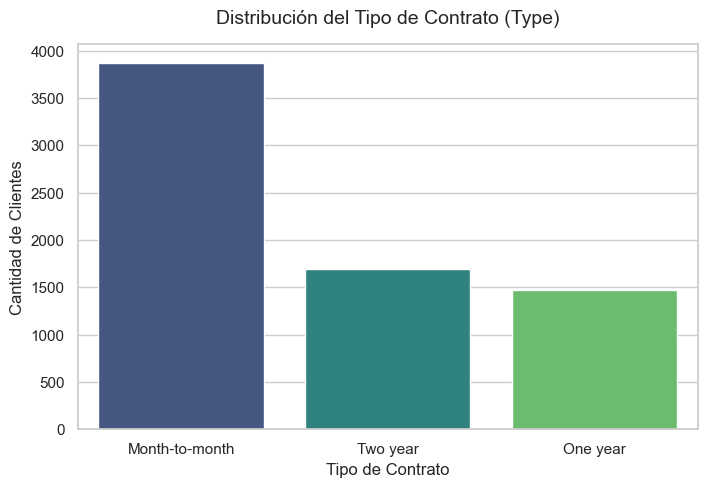

In [15]:
conteo= contract['Type'].value_counts()
porcentaje_type = contract['Type'].value_counts(normalize=True) * 100
resultados = pd.DataFrame({'Total Clientes': conteo,'Porcentaje (%)': porcentaje_type.round(2)})

#  Configurar el tamaño y estilo del gráfico
plt.figure(figsize=(8, 5))
sns.set_theme(style="whitegrid")  # Agrega una cuadrícula de fondo limpia

# Crear el gráfico de barras (usando 'Type')
# El parámetro order asegura que las barras se muestren de la categoría más alta a la más baja
sns.countplot(
    data=contract, 
    x='Type', 
    order=contract['Type'].value_counts().index, 
    palette='viridis'
)

#textos del gráfico
plt.title('Distribución del Tipo de Contrato (Type)', fontsize=14, pad=15)
plt.xlabel('Tipo de Contrato', fontsize=12)
plt.ylabel('Cantidad de Clientes', fontsize=12)

# 4. Mostrar el gráfico en pantalla
plt.show()

### Interpretación del grafico de distribución del tipo de contrato
Observamos el numero de los contratos de los clientes que tiene contratado de mes a mes y es más de doble de los clientes que tienen contrato por 2 años, mientras que los contratos de 1 año don lo menores, de esta manera podemos observar que son casí 4000 clientes que no tienen contrato a largo plazo y pueden irse sin atadiras.


C:\Users\Lalo\AppData\Local\Temp\ipykernel_6652\2113007272.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(


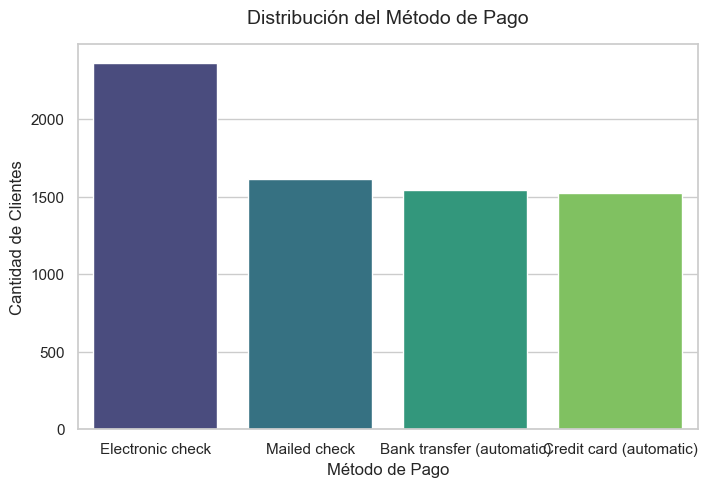

In [16]:
#Distribución de la columna metodo de pago "PaymentMethod"
conteo_payment= contract['PaymentMethod'].value_counts()
porcentaje_payment = contract['PaymentMethod'].value_counts(normalize=True) * 100
resultados_payment = pd.DataFrame({'Total Clientes': conteo_payment,'Porcentaje (%)': porcentaje_payment.round(2)})

#  Configurar el tamaño y estilo del gráfico
plt.figure(figsize=(8, 5))
# Crear el gráfico de barras (usando 'paymentMethod')
# El parámetro order asegura que las barras se muestren de la categoría más alta a la más baja
sns.countplot(
    data=contract, 
    x='PaymentMethod', 
    order=contract['PaymentMethod'].value_counts().index, 
    palette='viridis'
)

#textos del gráfico
plt.title('Distribución del Método de Pago', fontsize=14, pad=15)
plt.xlabel('Método de Pago', fontsize=12)
plt.ylabel('Cantidad de Clientes', fontsize=12)

# 4. Mostrar el gráfico en pantalla
plt.show()


### Interpretación del grafico de distribución del tipo de pago
Los llamados echeck son el método favorio de pago de las facturas de los clientes quizá por el bajo costo de comisiones, en segundo lugar encontramos al cheque tradicional, mientras que la transferencia bancaría y pago con tarjeta de credito son las menos populares.

C:\Users\Lalo\AppData\Local\Temp\ipykernel_6652\4050152018.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(


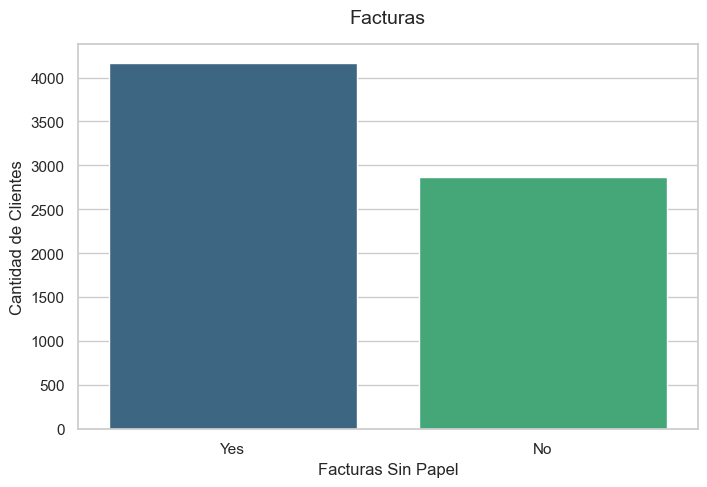

In [17]:
factura= contract['PaperlessBilling'].value_counts()
porcentaje_factura = contract['PaperlessBilling'].value_counts(normalize=True) * 100

tabla_factura = pd.DataFrame({'Total Clientes': factura,'Porcentaje (%)': porcentaje_factura.round(2)})

#  Configurar el tamaño y estilo del gráfico
plt.figure(figsize=(8, 5))

# Crear el gráfico de barras (usando 'paymentMethod')
# El parámetro order asegura que las barras se muestren de la categoría más alta a la más baja
sns.countplot(
    data=contract, 
    x='PaperlessBilling', 
    order=contract['PaperlessBilling'].value_counts().index, 
    palette='viridis'
)

#textos del gráfico
plt.title('Facturas', fontsize=14, pad=15)
plt.xlabel('Facturas Sin Papel', fontsize=12)
plt.ylabel('Cantidad de Clientes', fontsize=12)

#4. Mostrar el gráfico en pantalla
plt.show()


### Interpretación del grafico de distribución de factruas

La mayoría de los clientes (más de 42000) de manera menos tradicional esperan que les llegue las factuas de manera electronica, mientras que al rededord de 2900 clientes esperan que les llege las factuas de manera tradicional. 



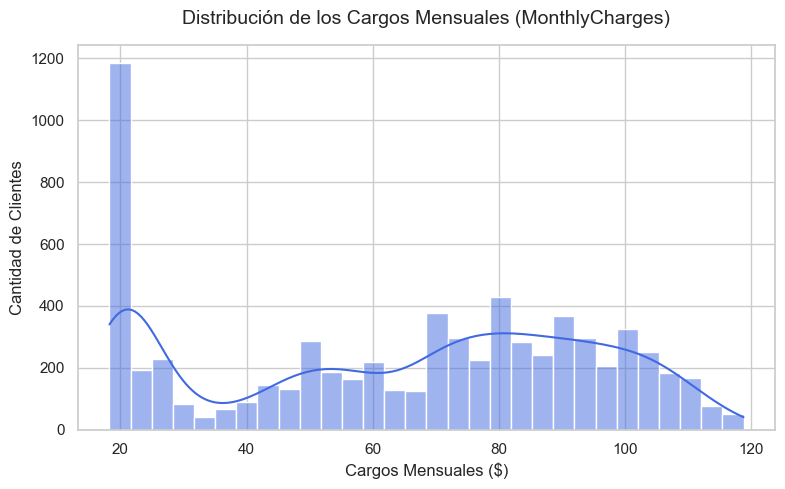

In [18]:
# Configurar el tamaño del gráfico
plt.figure(figsize=(9, 5))
sns.set_theme(style="whitegrid")

# Crear el histograma con línea de densidad (kde=True)
sns.histplot(
    data=contract, 
    x='MonthlyCharges', 
    kde=True, 
    bins=30,          # Divide los montos en 30 barras para ver mejor el detalle
    color='royalblue'
)

#Personalizar títulos y etiquetas
plt.title('Distribución de los Cargos Mensuales (MonthlyCharges)', fontsize=14, pad=15)
plt.xlabel('Cargos Mensuales ($)', fontsize=12)
plt.ylabel('Cantidad de Clientes', fontsize=12)

# Mostrar el gráfico
plt.show()




### Interpretación del grafico de cargos mensuales
Los clientes que pagan 20 dólares son la mayoría con al redor de los 1200 clientes, sorpendentemente  los clientes que pagan 80 doalres son los segundos con mayor pagos mensuales con al dedor de 400, mientras que los clinetes que pagan 35 dólares son al rededor de 20. Esto nos deja ver que hay planes populares tanto de 20 dólares cómo de los 70 a 100 dólares.  


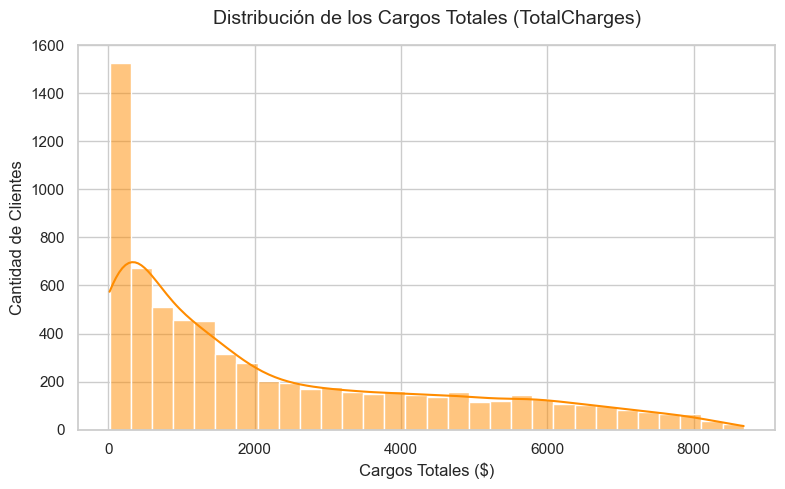

In [19]:

#Configuiración del tamaño y estilo del gráfico
plt.figure(figsize=(9, 5))
sns.set_theme(style="whitegrid")

#Crear histograma con línea de densidad (kde=True) para la columna TotalCharges
sns.histplot(
    data=contract,
    x='TotalCharges',
    kde=True,
    bins=30,
    color='darkorange'
)

#estilos de títulos y etiquetas
plt.title('Distribución de los Cargos Totales (TotalCharges)', fontsize=14, pad=15)
plt.xlabel('Cargos Totales ($)', fontsize=12)
plt.ylabel('Cantidad de Clientes', fontsize=12)

#Mostrar el gráfico
plt.show()

### Interpretación del grafico de distribución de los cargos totales

a distribución de TotalCharges presenta un marcado sesgo positivo, concentrando una gran cantidad de clientes con cargos acumulados bajos y disminuyendo progresivamente conforme aumenta el monto total facturado. Este comportamiento es consistente con un servicio donde conviven clientes de reciente incorporación con otros que llevan varios años contratando los servicios de la empresa. Asimismo, no se observan valores atípicos o patrones que sugieran problemas evidentes en la calidad de los datos.

In [37]:
contract['TotalCharges'].skew()

np.float64(0.961642499724251)

#### La asimetría positiva calculada confirma visualmente el sesgo observado en el histograma.

In [20]:
conteo_contratos = contract['customerID'].value_counts()
print("Cantidad de contratos por cliente:")
print(conteo_contratos)

Cantidad de contratos por cliente:
customerID
7590-VHVEG    1
5575-GNVDE    1
3668-QPYBK    1
7795-CFOCW    1
9237-HQITU    1
             ..
6840-RESVB    1
2234-XADUH    1
4801-JZAZL    1
8361-LTMKD    1
3186-AJIEK    1
Name: count, Length: 7043, dtype: int64


## Conclusión

El análisis descriptivo muestra que el conjunto de datos está compuesto por 7,043 clientes, sin registros duplicados. La mayoría mantiene contratos mensuales, utiliza facturación electrónica y realiza sus pagos mediante cheque electrónico. Los cargos mensuales presentan una variabilidad considerable, mientras que los cargos acumulados reflejan diferencias importantes en la antigüedad de los clientes. Además, se confirma que 5,174 clientes permanecían activos al momento del corte de la información, por lo que la variable objetivo presenta un desbalance que deberá considerarse durante la etapa de modelado.

In [21]:
#Análisis inicial
#Se mostrará las primeras 5 filas de cada uno de los archivos
personal.head()

,customerID,gender,SeniorCitizen,Partner,Dependents
0,7590-VHVEG,Female,0,Yes,No
1,5575-GNVDE,Male,0,No,No
2,3668-QPYBK,Male,0,No,No
3,7795-CFOCW,Male,0,No,No
4,9237-HQITU,Female,0,No,No


In [22]:
#ver valores faltantes
personal.isna().sum()

customerID       0
gender           0
SeniorCitizen    0
Partner          0
Dependents       0
dtype: int64

In [23]:
#Análisis inicial
#Ver total de filas y columnas
personal.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 5 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   customerID     7043 non-null   object
 1   gender         7043 non-null   object
 2   SeniorCitizen  7043 non-null   int64 
 3   Partner        7043 non-null   object
 4   Dependents     7043 non-null   object
dtypes: int64(1), object(4)
memory usage: 275.2+ KB


In [24]:
#Análisis inicial
#Se mostrará las primeras 5 filas de cada uno de los archivos
internet.head()

,customerID,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies
0,7590-VHVEG,DSL,No,Yes,No,No,No,No
1,5575-GNVDE,DSL,Yes,No,Yes,No,No,No
2,3668-QPYBK,DSL,Yes,Yes,No,No,No,No
3,7795-CFOCW,DSL,Yes,No,Yes,Yes,No,No
4,9237-HQITU,Fiber optic,No,No,No,No,No,No


In [25]:
#ver valores faltantes
internet.isna().sum()

customerID          0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
dtype: int64

In [26]:
#Análisis inicial
#Ver total de filas y columnas
internet.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5517 entries, 0 to 5516
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   customerID        5517 non-null   object
 1   InternetService   5517 non-null   object
 2   OnlineSecurity    5517 non-null   object
 3   OnlineBackup      5517 non-null   object
 4   DeviceProtection  5517 non-null   object
 5   TechSupport       5517 non-null   object
 6   StreamingTV       5517 non-null   object
 7   StreamingMovies   5517 non-null   object
dtypes: object(8)
memory usage: 344.9+ KB


In [27]:
#Análisis inicial
#Se mostrará las primeras 5 filas de cada uno de los archivos
phone.head()

,customerID,MultipleLines
0,5575-GNVDE,No
1,3668-QPYBK,No
2,9237-HQITU,No
3,9305-CDSKC,Yes
4,1452-KIOVK,Yes


In [28]:
#Análisis inicial
#Ver total de filas y columnas
phone.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6361 entries, 0 to 6360
Data columns (total 2 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   customerID     6361 non-null   object
 1   MultipleLines  6361 non-null   object
dtypes: object(2)
memory usage: 99.5+ KB


In [29]:
#ver valores faltantes
phone.isna().sum()

customerID       0
MultipleLines    0
dtype: int64

## Preguntas aclaratorias

1. ¿Existe algún costo o impacto de negocio asociado a clasificar incorrectamente a un cliente? Por ejemplo, ¿es preferible identificar a la mayor cantidad posible de clientes que cancelarán, aunque aumenten los falsos positivos?

2. Además de maximizar la métrica ROC-AUC, ¿la interpretabilidad del modelo será un criterio importante para el equipo de marketing al momento de utilizar la solución?

3. ¿Hay algún indicador de negocio adicional que deba incluirse en las recomendaciones finales, además de la predicción de cancelación de clientes?

## Plan de trabajo

### Paso 1. Comprensión e integración de los datos
Explorar cada uno de los conjuntos de datos para comprender su estructura, verificar la calidad de la información y unirlos mediante la columna `customerID` para obtener un único conjunto de datos que represente a cada cliente.

### Paso 2. Preparación y transformación de los datos
Crear la variable objetivo a partir de la columna `EndDate`, corregir tipos de datos, tratar valores faltantes y generar variables que puedan aportar información relevante para mejorar el desempeño del modelo.

### Paso 3. Análisis exploratorio de datos
Analizar las características de los clientes y su relación con la cancelación del servicio mediante estadísticas descriptivas y visualizaciones, con el fin de identificar patrones que apoyen la selección de variables.

### Paso 4. Desarrollo y evaluación de modelos
Entrenar distintos modelos de clasificación, ajustar sus hiperparámetros y compararlos utilizando principalmente la métrica ROC-AUC, considerando también la exactitud como métrica complementaria para seleccionar la mejor alternativa.

### Paso 5. Interpretación de resultados y recomendaciones
Analizar la importancia de las variables del modelo seleccionado, interpretar los resultados desde la perspectiva del negocio y elaborar recomendaciones que ayuden al equipo de marketing a implementar estrategias de retención de clientes.